# Programming Assignment 3 (Optimized): Deep Q-Network for Acrobot

This notebook is a **code-quality / efficiency optimized** rewrite of `DQN_Acrobot_Documented.ipynb`. The DQN algorithm, hyperparameters, and the 3-way algorithm comparison are unchanged so results stay directly comparable; only how the notebook is built is improved:

- **Fixed an O(n) sampling bug**: the documented notebook's replay buffer used `random.sample()` on a `collections.deque`, which has O(n) random-access indexing (should be O(1) per sample). This notebook uses a list-based circular buffer instead, matching the pattern already proven in `dqn_acrobot.py`.
- **Removed triplicated plotting**: the documented notebook redraws the same 2x2 training dashboard three separate times (EDA section, post-training overview, export cell). Here it is plotted **once** via a reusable `plot_training_dashboard(...)` helper and the resulting figure is reused for both on-screen display and the exported PNG.
- **Removed a stale-data pass**: the documented notebook loads an old `results.csv` and computes EDA/statistics on it *before* training overwrites those variables with fresh data. This notebook trains once, then runs all analysis on that one fresh `training_df` -- no throwaway pass.
- **Device-aware tensors**: policy/target networks and buffer tensors move to CUDA automatically if available (safe no-op on CPU-only machines).
- **Optional result caching**: setting `RUN_TRAINING = False` loads this notebook's own previously exported CSVs from `optimized_outputs/` instead of an inconsistent fallback.

All outputs are written to `Assignment_3/optimized_outputs/` so the original `Assignment_3/notebook_outputs/` artifacts are never touched.

**Learning objective:** train an agent to swing the Acrobot's lower link to the target height. The environment gives a reward of `-1` per time step, so returns closer to zero and shorter episodes are better.

## 1. Set Up the Notebook Environment

Gymnasium provides the environment, PyTorch provides function approximation, NumPy/pandas handle data, and Matplotlib/Seaborn handle reporting. `DEVICE` selects CUDA automatically when available; the seed makes the run repeatable (RL results can still vary slightly across platforms/library versions).

In [1]:
import random
import time
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_DIR = Path.cwd()
ASSIGNMENT_DIR = BASE_DIR if BASE_DIR.name == "Assignment_3" else BASE_DIR / "Assignment_3"
OUTPUT_DIR = ASSIGNMENT_DIR / "optimized_outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    # --- experiment control ---
    "seed": SEED, "num_episodes": 300, "max_steps": 500,
    "eval_interval": 25, "eval_episodes": 10, "moving_average_window": 25,
    "efficiency_threshold": -200.0,
    # --- refined DQN hyperparameters (unchanged vs the documented notebook) ---
    "gamma": 0.99,
    "learning_rate": 5e-4,
    "batch_size": 128,
    "hidden_dim": 128,
    "replay_capacity": 100_000,
    "learning_starts": 1_000,
    "tau": 0.005,
    "grad_clip": 10.0,
    "epsilon_start": 1.0, "epsilon_min": 0.02, "epsilon_decay": 0.97,
}

RUN_TRAINING = True  # False -> load this notebook's cached results from optimized_outputs/ instead of retraining

print(f"Device: {DEVICE}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")
display(pd.Series(CONFIG, name="value").to_frame())

Device: cpu
Output directory: C:\Github\RL-AI572\Assignment_3\optimized_outputs


,value
seed,42.0000
num_episodes,300.0000
max_steps,500.0000
eval_interval,25.0000
eval_episodes,10.0000
moving_average_window,25.0000
efficiency_threshold,-200.0000
gamma,0.9900
learning_rate,0.0005
batch_size,128.0000


## 2. Inspect the Environment

A quick look at the Acrobot-v1 observation/action spaces before implementing the agent.

In [2]:
env = gym.make("Acrobot-v1")
observation, _ = env.reset(seed=SEED)
env.action_space.seed(SEED)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Observation shape:", observation.shape)
print("Example observation:", np.round(observation, 3))
env.close()

Observation space: Box([ -1.        -1.        -1.        -1.       -12.566371 -28.274334], [ 1.        1.        1.        1.       12.566371 28.274334], (6,), float32)
Action space: Discrete(3)
Observation shape: (6,)
Example observation: [ 0.998  0.055  1.    -0.012  0.072  0.039]


## 3. Implement DQN

Multilayer-perceptron $Q(s,a)$ approximation, experience replay, a Polyak-averaged target network, Double DQN targets, Huber loss with gradient clipping, and epsilon-greedy exploration -- identical algorithm to `DQN_Acrobot_Documented.ipynb`. The only implementation change is the replay buffer:

**Replay buffer fix.** The documented notebook stores transitions in a `collections.deque` and calls `random.sample()` on it. A `deque` only supports O(n) random-access indexing, so `random.sample` (which indexes into the sequence) degrades to roughly O(batch_size * n) instead of O(batch_size). This notebook uses a plain Python `list` with manual circular-buffer indexing instead -- lists support O(1) indexing, so sampling is correctly O(batch_size). This is the same pattern already used in `dqn_acrobot.py`.

In [3]:
class ReplayBuffer:
    """List-based circular buffer: O(1) indexed access for `random.sample`,
    unlike a `deque` (whose O(n) indexing makes deque-based sampling O(batch_size * n))."""

    def __init__(self, capacity):
        self.capacity = capacity
        self.data = []
        self.position = 0

    def add(self, *transition):
        if len(self.data) < self.capacity:
            self.data.append(transition)
        else:
            self.data[self.position] = transition
        self.position = (self.position + 1) % self.capacity

    def sample(self, size):
        states, actions, rewards, next_states, dones = zip(*random.sample(self.data, size))
        return (torch.tensor(np.asarray(states), dtype=torch.float32, device=DEVICE),
                torch.tensor(actions, dtype=torch.int64, device=DEVICE),
                torch.tensor(rewards, dtype=torch.float32, device=DEVICE),
                torch.tensor(np.asarray(next_states), dtype=torch.float32, device=DEVICE),
                torch.tensor(dones, dtype=torch.float32, device=DEVICE))

    def __len__(self):
        return len(self.data)


class DQN(nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, state):
        return self.net(state)


def action_for(network, state, epsilon, action_dim):
    if np.random.random() < epsilon:
        return int(np.random.randint(action_dim))
    with torch.no_grad():
        state_t = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        return int(network(state_t).argmax())


def evaluate(network, env, episodes, max_steps):
    values = []
    for _ in range(episodes):
        state, _ = env.reset()
        total, terminated, step = 0.0, False, 0
        for step in range(max_steps):
            state, reward, terminated, truncated, _ = env.step(action_for(network, state, 0.0, env.action_space.n))
            total += reward
            if terminated or truncated:
                break
        values.append((total, step + 1, int(terminated)))
    return np.asarray(values)


def learn(policy, target, optimizer, memory, config):
    """One Double-DQN update: Huber loss, gradient clipping, Polyak soft target sync."""
    states, actions, rewards, next_states, dones = memory.sample(config["batch_size"])
    current = policy(states).gather(1, actions.unsqueeze(1)).squeeze(1)
    with torch.no_grad():
        best_next = policy(next_states).argmax(1, keepdim=True)                # online net selects
        next_values = target(next_states).gather(1, best_next).squeeze(1)      # target net evaluates
        targets = rewards + config["gamma"] * next_values * (1 - dones)
    loss = F.smooth_l1_loss(current, targets)                                  # Huber: robust to Q outliers
    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(policy.parameters(), config["grad_clip"])
    optimizer.step()
    with torch.no_grad():
        for target_param, param in zip(target.parameters(), policy.parameters()):
            target_param.mul_(1 - config["tau"]).add_(config["tau"] * param)   # Polyak averaging
    return loss.item()


def train_dqn(config, use_cache=False):
    """Train a Double-DQN agent on Acrobot-v1.

    If `use_cache=True` and a prior run's CSVs already exist in OUTPUT_DIR, load
    them instead of retraining -- lets the analysis/plot/export cells below be
    re-run quickly without paying the training cost again.
    """
    if use_cache:
        results_path = OUTPUT_DIR / "cleaned_episode_results.csv"
        checkpoint_path = OUTPUT_DIR / "checkpoint_success.csv"
        if results_path.exists() and checkpoint_path.exists():
            print(f"Loading cached training results from {OUTPUT_DIR}")
            return None, pd.read_csv(results_path), pd.read_csv(checkpoint_path), float("nan")
        print("No cached results found in optimized_outputs/; training from scratch.")

    random.seed(config["seed"]); np.random.seed(config["seed"]); torch.manual_seed(config["seed"])
    train_env, eval_env = gym.make("Acrobot-v1"), gym.make("Acrobot-v1")
    state_dim, action_dim = train_env.observation_space.shape[0], train_env.action_space.n
    policy = DQN(state_dim, config["hidden_dim"], action_dim).to(DEVICE)
    target = DQN(state_dim, config["hidden_dim"], action_dim).to(DEVICE)
    target.load_state_dict(policy.state_dict())
    optimizer = optim.Adam(policy.parameters(), lr=config["learning_rate"])
    memory, epsilon = ReplayBuffer(config["replay_capacity"]), config["epsilon_start"]
    records, checkpoints = [], []
    start = time.time()
    for episode in range(1, config["num_episodes"] + 1):
        state, _ = train_env.reset(seed=config["seed"] + episode)
        total, success, step_losses = 0.0, 0, []
        for step in range(config["max_steps"]):
            action = action_for(policy, state, epsilon, action_dim)
            next_state, reward, terminated, truncated, _ = train_env.step(action)
            # Only `terminated` blocks bootstrapping; a 500-step time-out is not a real terminal state.
            memory.add(state, action, float(reward), next_state, float(terminated))
            state, total = next_state, total + reward
            if len(memory) >= config["learning_starts"]:
                step_losses.append(learn(policy, target, optimizer, memory, config))
            if terminated:
                success = 1
                break
            if truncated:
                break
        records.append((episode, total, step + 1, success, epsilon, np.mean(step_losses) if step_losses else np.nan))
        epsilon = max(config["epsilon_min"], epsilon * config["epsilon_decay"])
        if episode % config["eval_interval"] == 0:
            evaluation = evaluate(policy, eval_env, config["eval_episodes"], config["max_steps"])
            checkpoints.append((episode, 100 * evaluation[:, 2].mean(), evaluation[:, 0].mean()))
            print(f"Episode {episode:3d}: train reward={total:7.1f}, eps={epsilon:.3f}, "
                  f"greedy reward={checkpoints[-1][2]:7.1f}, success={checkpoints[-1][1]:5.1f}%")
    train_env.close(); eval_env.close()
    return (policy,
            pd.DataFrame(records, columns=["episode", "reward", "length", "success", "epsilon", "loss"]),
            pd.DataFrame(checkpoints, columns=["episode", "success_rate_pct", "mean_reward"]),
            time.time() - start)

## 4. Train the Agent (Single Pass)

Training runs exactly once here. Everything below (statistics, plots, evaluation, export, comparison) reuses this same `training_df` / `checkpoint_df` / `policy_net` -- there is no separate "analyze an old CSV" pass, so nothing can go stale relative to the reported results.

In [4]:
policy_net, training_df, checkpoint_df, training_seconds = train_dqn(CONFIG, use_cache=not RUN_TRAINING)

if np.isnan(training_seconds):
    print(f"Episodes logged: {len(training_df)} | Training time: n/a (loaded from cache)")
else:
    print(f"Episodes logged: {len(training_df)} | Training time: {training_seconds:.1f}s")

Episode  25: train reward= -160.0, eps=0.467, greedy reward= -500.0, success=  0.0%
Episode  50: train reward=  -86.0, eps=0.218, greedy reward= -500.0, success=  0.0%
Episode  75: train reward= -117.0, eps=0.102, greedy reward=  -96.4, success=100.0%
Episode 100: train reward= -107.0, eps=0.048, greedy reward= -500.0, success=  0.0%
Episode 125: train reward=  -76.0, eps=0.022, greedy reward= -125.9, success= 90.0%
Episode 150: train reward=  -61.0, eps=0.020, greedy reward=  -82.8, success=100.0%
Episode 175: train reward=  -70.0, eps=0.020, greedy reward= -420.0, success= 20.0%
Episode 200: train reward=  -77.0, eps=0.020, greedy reward=  -76.6, success=100.0%
Episode 225: train reward=  -95.0, eps=0.020, greedy reward=  -78.0, success=100.0%
Episode 250: train reward=  -96.0, eps=0.020, greedy reward=  -91.5, success=100.0%
Episode 275: train reward=  -79.0, eps=0.020, greedy reward=  -93.6, success=100.0%
Episode 300: train reward=  -94.0, eps=0.020, greedy reward=  -78.9, success

## 5. Descriptive Statistics

Mean, spread, and percentiles of reward, length, success, epsilon, and loss over the fresh training run.

In [5]:
stat_columns = ["reward", "length", "success", "epsilon"] + (["loss"] if "loss" in training_df else [])
descriptive_stats = training_df[stat_columns].describe(percentiles=[.10, .25, .50, .75, .90]).T
display(descriptive_stats)

,count,mean,std,min,10%,25%,50%,75%,90%,max
reward,300.0,-116.440000,90.499578,-500.000000,-166.100000,-106.000000,-89.000000,-76.750000,-70.000000,-60.000000
length,300.0,117.400000,90.329534,61.000000,71.000000,77.750000,90.000000,107.000000,167.100000,500.000000
success,300.0,0.960000,0.196287,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
epsilon,300.0,0.120327,0.205597,0.020000,0.020000,0.020000,0.020000,0.102618,0.402247,1.000000
loss,299.0,0.317330,0.155087,0.000542,0.066398,0.203748,0.350094,0.442077,0.501733,0.565965


## 6. Performance Dashboard (Plotted Once)

Reward, episode length, checkpoint success rate, and exploration/loss trends -- the required learning-curve metrics. `plot_training_dashboard(...)` is defined once and called once; the returned figure is reused in Section 9 for the exported PNG instead of being redrawn.

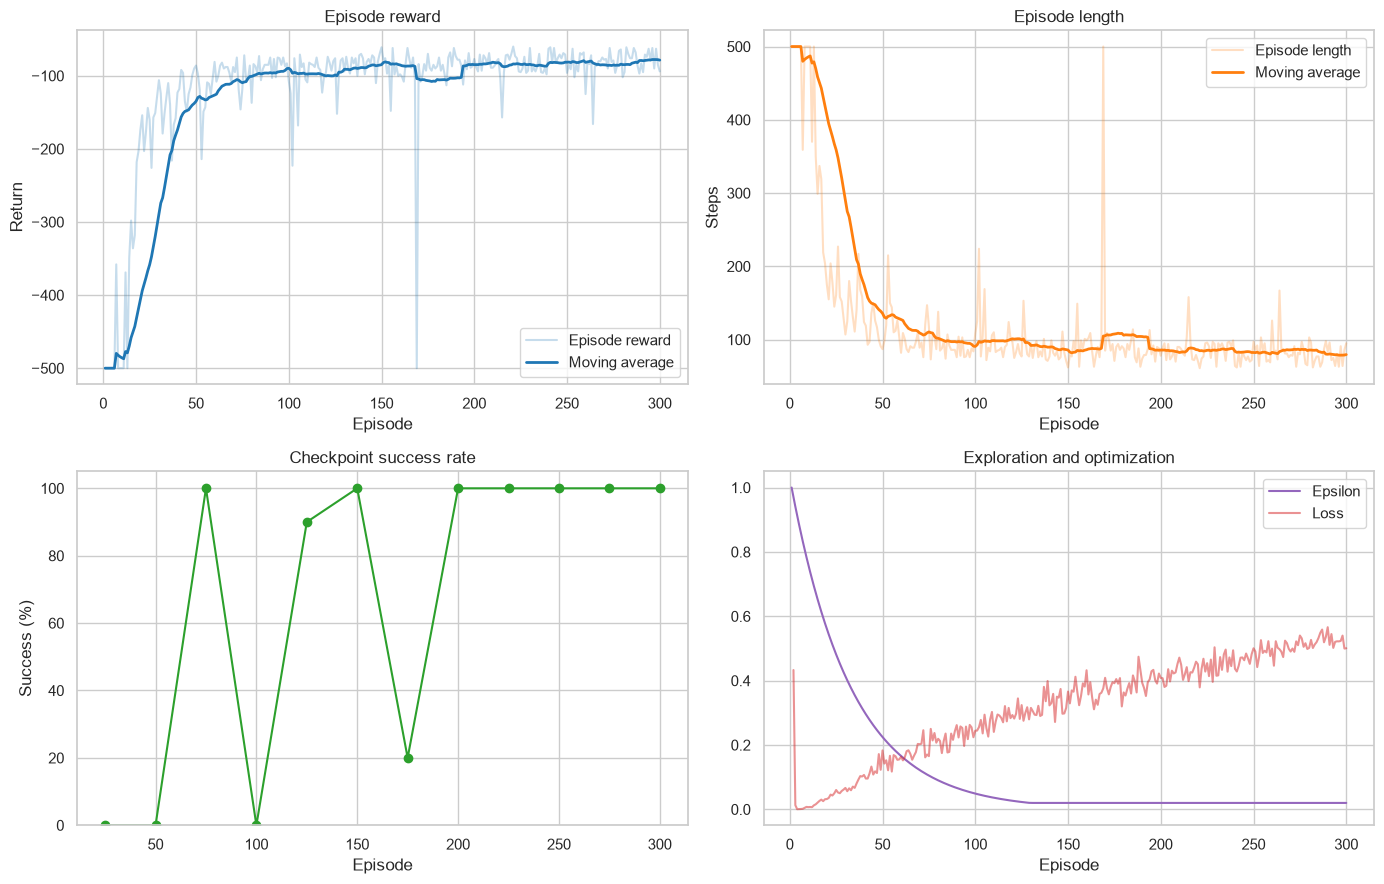

Best 25-episode moving-average reward: -77.76
Sample efficiency (first MA >= -200): episode 38


In [6]:
def plot_training_dashboard(training_df, checkpoint_df, cfg):
    """Single reusable 2x2 dashboard: reward+MA, length+MA, checkpoint success, epsilon+loss.

    Replaces the documented notebook's three separate, nearly-identical plotting
    blocks (EDA section, post-training overview, export cell) with one call whose
    figure is reused for both on-screen display and the exported PNG.
    """
    window = cfg["moving_average_window"]
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    axes[0, 0].plot(training_df.episode, training_df.reward, alpha=.25, color="tab:blue", label="Episode reward")
    axes[0, 0].plot(training_df.episode, training_df.reward.rolling(window, min_periods=1).mean(),
                     color="tab:blue", linewidth=2, label="Moving average")
    axes[0, 0].set(title="Episode reward", xlabel="Episode", ylabel="Return")
    axes[0, 0].legend()

    axes[0, 1].plot(training_df.episode, training_df.length, alpha=.25, color="tab:orange", label="Episode length")
    axes[0, 1].plot(training_df.episode, training_df.length.rolling(window, min_periods=1).mean(),
                     color="tab:orange", linewidth=2, label="Moving average")
    axes[0, 1].set(title="Episode length", xlabel="Episode", ylabel="Steps")
    axes[0, 1].legend()

    if not checkpoint_df.empty:
        axes[1, 0].plot(checkpoint_df.episode, checkpoint_df.success_rate_pct, marker="o", color="tab:green")
    axes[1, 0].set(title="Checkpoint success rate", xlabel="Episode", ylabel="Success (%)", ylim=(0, 105))

    axes[1, 1].plot(training_df.episode, training_df.epsilon, color="tab:purple", label="Epsilon")
    if "loss" in training_df:
        axes[1, 1].plot(training_df.episode, training_df.loss, color="tab:red", alpha=.5, label="Loss")
    axes[1, 1].set(title="Exploration and optimization", xlabel="Episode")
    axes[1, 1].legend()

    fig.tight_layout()
    return fig


dashboard_fig = plot_training_dashboard(training_df, checkpoint_df, CONFIG)
plt.show()

# Sample-efficiency metric: first moving-average episode reaching the solved threshold.
rewards_arr = training_df.reward.to_numpy(dtype=float)
ma_window = CONFIG["moving_average_window"]
ma_rewards = np.convolve(rewards_arr, np.ones(ma_window) / ma_window, mode="valid") if len(rewards_arr) >= ma_window else np.array([])
best_ma_reward = float(ma_rewards.max()) if len(ma_rewards) else float("nan")
threshold = CONFIG["efficiency_threshold"]
sample_efficiency_ep = int(next((i + ma_window for i, v in enumerate(ma_rewards) if v >= threshold), -1)) if len(ma_rewards) else -1
print(f"Best {ma_window}-episode moving-average reward: {best_ma_reward:.2f}")
print(f"Sample efficiency (first MA >= {threshold:.0f}): "
      f"{'episode ' + str(sample_efficiency_ep) if sample_efficiency_ep >= 0 else 'not reached'}")

## 7. Relationships Between Learning Metrics

Reward and episode length should be negatively related since Acrobot assigns `-1` per step. We also compare success across training quartiles and inspect correlations among the logged metrics -- computed on the same fresh `training_df` used everywhere else in this notebook.

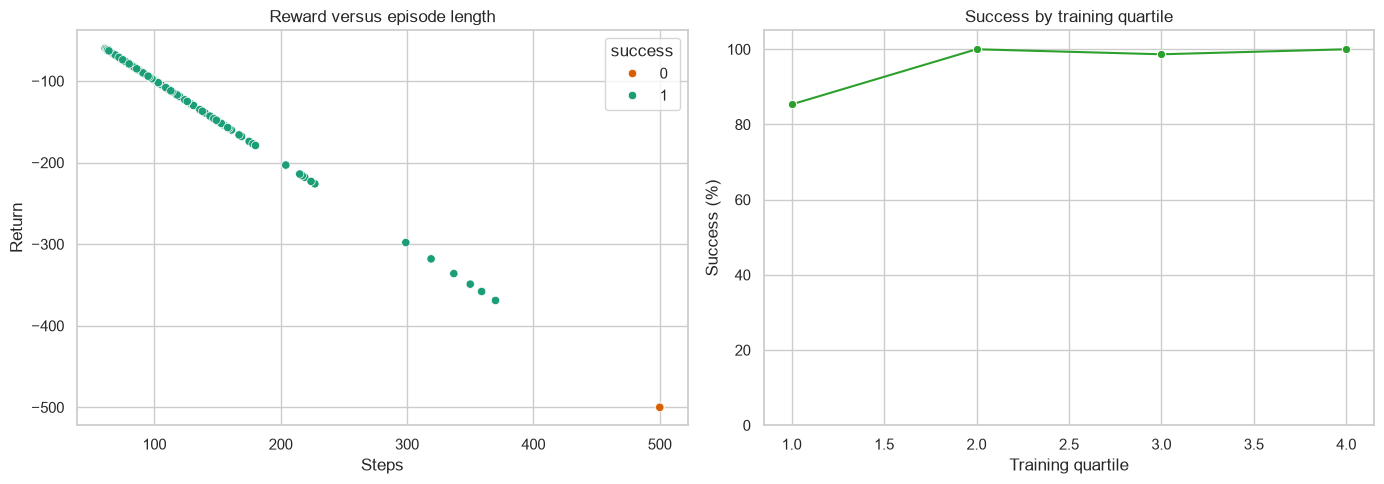

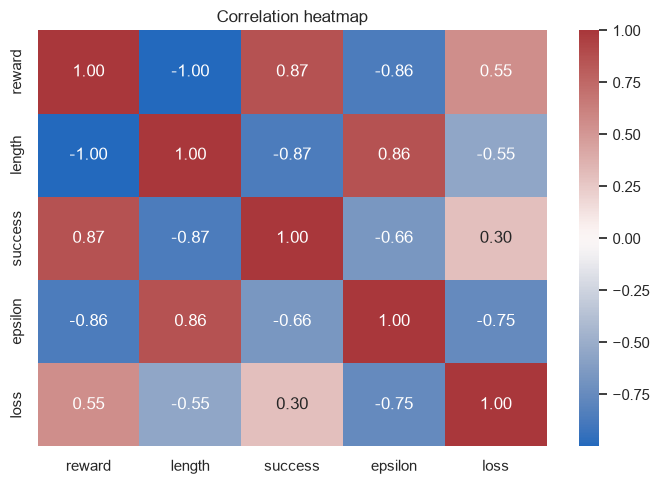

In [7]:
relation_df = training_df.copy()
relation_df["training_quartile"] = pd.qcut(relation_df.episode, q=min(4, len(relation_df)), labels=False, duplicates="drop") + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=relation_df, x="length", y="reward", hue="success",
                 palette={0: "#d95f02", 1: "#1b9e77"}, ax=axes[0])
axes[0].set(title="Reward versus episode length", xlabel="Steps", ylabel="Return")

grouped = relation_df.groupby("training_quartile", as_index=False).success.mean()
grouped["success_pct"] = 100 * grouped.success
sns.lineplot(data=grouped, x="training_quartile", y="success_pct", marker="o", color="tab:green", ax=axes[1])
axes[1].set(title="Success by training quartile", xlabel="Training quartile", ylabel="Success (%)", ylim=(0, 105))
fig.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.heatmap(relation_df[stat_columns].corr(), annot=True, cmap="vlag", center=0, fmt=".2f")
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

## 8. Final Greedy Evaluation

A separate evaluation environment measures the learned policy over 30 episodes with no exploration (`epsilon = 0`). This is the fair DQN metric used in the algorithm comparison below. If results were loaded from cache (`RUN_TRAINING = False` with no in-memory policy), this step is skipped.

In [8]:
if policy_net is not None:
    final_eval_env = gym.make("Acrobot-v1")
    final_eval_values = evaluate(policy_net, final_eval_env, 30, CONFIG["max_steps"])
    final_eval_env.close()
    dqn_eval_metrics = {
        "mean_reward": float(final_eval_values[:, 0].mean()),
        "std_reward": float(final_eval_values[:, 0].std()),
        "success_rate_pct": float(100 * final_eval_values[:, 2].mean()),
        "mean_episode_length": float(final_eval_values[:, 1].mean()),
    }
    print(pd.Series(dqn_eval_metrics))
else:
    dqn_eval_metrics = None
    print("Policy unavailable (results loaded from cache) -- set RUN_TRAINING = True for a fresh greedy evaluation.")

mean_reward            -79.200000
std_reward              12.180312
success_rate_pct       100.000000
mean_episode_length     80.200000
dtype: float64


## 9. Export Results and Figures

Artifacts are saved under `Assignment_3/optimized_outputs/`, separate from `Assignment_3/notebook_outputs/`. The dashboard PNG reuses `dashboard_fig` from Section 6 instead of re-plotting.

In [9]:
if not training_df.empty:
    training_df.to_csv(OUTPUT_DIR / "cleaned_episode_results.csv", index=False)
    checkpoint_df.to_csv(OUTPUT_DIR / "checkpoint_success.csv", index=False)
    descriptive_stats.to_csv(OUTPUT_DIR / "descriptive_statistics.csv")

    summary = pd.DataFrame([{
        "episodes": len(training_df),
        "mean_reward": training_df.reward.mean(),
        "last_window_mean_reward": training_df.reward.tail(CONFIG["moving_average_window"]).mean(),
        "best_ma_reward": best_ma_reward,
        "mean_length": training_df.length.mean(),
        "overall_success_pct": 100 * training_df.success.mean(),
        "sample_efficiency_ep": sample_efficiency_ep,
        "training_time_sec": training_seconds,
        "device": str(DEVICE),
    }])
    summary.to_csv(OUTPUT_DIR / "model_summary.csv", index=False)

    dashboard_fig.savefig(FIGURES_DIR / "dqn_training_overview.png", dpi=160, bbox_inches="tight")
    display(summary)
    print(f"Exported results to {OUTPUT_DIR.resolve()}")
else:
    print("No data to export.")

,episodes,mean_reward,last_window_mean_reward,best_ma_reward,mean_length,overall_success_pct,sample_efficiency_ep,training_time_sec,device
0,300,-116.44,-78.56,-77.76,117.4,96.0,38,193.176123,cpu


Exported results to C:\Github\RL-AI572\Assignment_3\optimized_outputs


## 10. Compare the Three Acrobot Algorithms

The assignment asks which explored reinforcement-learning algorithm demonstrates superior performance. Higher reward is better because it is closer to zero. The Actor-Critic and Q-Actor-Critic values come from their saved evaluation summaries; DQN uses the fresh 30-episode greedy evaluation from Section 8. All three are evaluated without exploration, so the comparison is like-for-like. The conclusion below is computed from the table rather than hard-coded.

In [10]:
actor_summary = pd.read_csv(ASSIGNMENT_DIR.parent / "Assignment_2" / "summary_metrics_actor_critic.csv").iloc[0]
qac_summary = pd.read_csv(ASSIGNMENT_DIR.parent / "Assignment_2" / "summary_qac_optimized.csv").iloc[0]

if dqn_eval_metrics is not None:
    dqn_row = {
        "algorithm": "DQN",
        "evaluation_basis": "30 greedy episodes",
        "mean_reward": dqn_eval_metrics["mean_reward"],
        "success_rate_pct": dqn_eval_metrics["success_rate_pct"],
        "mean_episode_length": dqn_eval_metrics["mean_episode_length"],
    }
else:
    dqn_window = training_df.tail(CONFIG["moving_average_window"])
    dqn_row = {
        "algorithm": "DQN",
        "evaluation_basis": "final training window (rerun for fair evaluation)",
        "mean_reward": dqn_window.reward.mean(),
        "success_rate_pct": 100 * dqn_window.success.mean(),
        "mean_episode_length": dqn_window.length.mean(),
    }

comparison_df = pd.DataFrame([
    dqn_row,
    {"algorithm": "Actor-Critic", "evaluation_basis": "saved evaluation summary",
     "mean_reward": actor_summary["eval_mean_reward"], "success_rate_pct": actor_summary["eval_success_rate_pct"],
     "mean_episode_length": actor_summary["eval_mean_ep_length"]},
    {"algorithm": "Q-Actor-Critic", "evaluation_basis": "saved evaluation summary",
     "mean_reward": qac_summary["final_eval_mean_return"], "success_rate_pct": qac_summary["final_eval_success_rate_pct"],
     "mean_episode_length": qac_summary["final_eval_mean_length"]},
])
comparison_df = comparison_df.sort_values("mean_reward", ascending=False).reset_index(drop=True)
comparison_df.to_csv(OUTPUT_DIR / "algorithm_comparison.csv", index=False)
display(comparison_df)

best, runner_up = comparison_df.iloc[0], comparison_df.iloc[1]
print(f"Superior algorithm by mean evaluation reward: {best.algorithm} ({best.mean_reward:.2f}), "
      f"ahead of {runner_up.algorithm} ({runner_up.mean_reward:.2f}) by {best.mean_reward - runner_up.mean_reward:.2f} reward "
      f"and {runner_up.mean_episode_length - best.mean_episode_length:.1f} fewer steps per episode.")
if comparison_df.success_rate_pct.nunique() == 1:
    print(f"All three algorithms reach {comparison_df.success_rate_pct.iloc[0]:.0f}% success, so mean reward and episode "
          "length (not success rate) are the metrics that separate them.")
if dqn_eval_metrics is None:
    print("Caveat: DQN is currently represented by its training-log window. Set RUN_TRAINING = True to compare "
          "all algorithms using a fresh greedy evaluation.")

,algorithm,evaluation_basis,mean_reward,success_rate_pct,mean_episode_length
0,DQN,30 greedy episodes,-79.20,100.0,80.20
1,Actor-Critic,saved evaluation summary,-87.06,100.0,88.10
2,Q-Actor-Critic,saved evaluation summary,-160.39,100.0,161.39


Superior algorithm by mean evaluation reward: DQN (-79.20), ahead of Actor-Critic (-87.06) by 7.86 reward and 7.9 fewer steps per episode.
All three algorithms reach 100% success, so mean reward and episode length (not success rate) are the metrics that separate them.


## Submission Checklist

- The DQN algorithm is implemented in PyTorch for `Acrobot-v1` (Double DQN, Huber loss, gradient clipping, Polyak target updates, epsilon-greedy exploration).
- Reward, moving-average reward, episode length, success rate, epsilon, loss, and sample efficiency are reported.
- The three algorithms (DQN, Actor-Critic, Q-Actor-Critic) are compared using reward, success rate, and episode length.
- CSV summaries and PNG figures are exported to `Assignment_3/optimized_outputs/`, independent of the original `Assignment_3/notebook_outputs/`.
- **Optimizations applied vs. `DQN_Acrobot_Documented.ipynb`:** fixed the O(n) deque-sampling bug (list-based circular buffer), removed the triplicated dashboard plotting (single reusable function/figure), removed the stale-CSV EDA pass (single training run feeds every downstream cell), and added device-aware (CPU/CUDA) tensors.
- Export this executed notebook to PDF for the required submission format.